# Machine Learning Project by Rizka Alfadilla: [BISINDO0]

## Packages/Library

In [ ]:
# Tunggu hingga semua library terinstall baru restart session

!pip install tensorflowjs

INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires pack

In [ ]:
# Menonaktifkan warning yang mungkin muncul
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# Library Umum
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# Machine Learning & Model Inference
import tensorflow as tf
import joblib
import tensorflowjs

# Pelatihan dan evaluasi
import seaborn as sns
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Mencetak versi Library yang sedang digunakan
print(f'Python Version: {sys.version.split()[0]}')
print(f'Pandas Version: {pd.__version__}')
print(f'Numpy Version: {np.__version__}')
print(f'Scikit Learn Version: {sklearn.__version__}')
print(f'Tensorflow Version: {tf.__version__}')
print(f'TensorFlow.js Version: {tensorflowjs.__version__}')

Python Version: 3.12.13
Pandas Version: 2.2.2
Numpy Version: 2.0.2
Scikit Learn Version: 1.6.1
Tensorflow Version: 2.19.0
TensorFlow.js Version: 4.22.0


## Data Preparation

### Data Loading

In [ ]:
df = pd.read_csv("bisindo_landmarks_scaled.csv")

df.head(10)

,label,left_0_x,left_0_y,left_0_z,left_1_x,left_1_y,left_1_z,left_2_x,left_2_y,left_2_z,...,right_17_z,right_18_x,right_18_y,right_18_z,right_19_x,right_19_y,right_19_z,right_20_x,right_20_y,right_20_z
0,A,0.0,0.0,0.0,0.156685,-0.005541,-0.047836,0.326597,-0.096635,-0.089321,...,-0.119791,-0.230589,-0.322556,-0.164190,-0.180070,-0.233319,-0.134155,-0.136272,-0.243931,-0.101799
1,A,0.0,0.0,0.0,0.124238,0.051174,-0.111407,0.275913,-0.007208,-0.168738,...,-0.133209,0.029571,-0.489174,-0.208708,0.039503,-0.347661,-0.176480,0.000339,-0.302568,-0.136870
2,A,0.0,0.0,0.0,0.130286,0.051193,-0.105222,0.282595,-0.011618,-0.156156,...,-0.141321,0.024570,-0.490553,-0.219102,0.035941,-0.349902,-0.188352,-0.005280,-0.299756,-0.149545
3,A,0.0,0.0,0.0,0.137191,-0.021136,-0.046313,0.283184,-0.164059,-0.077592,...,-0.114921,-0.093922,-0.406087,-0.152573,-0.081484,-0.300141,-0.121113,-0.047573,-0.310949,-0.087608
4,A,0.0,0.0,0.0,0.137996,-0.021240,-0.059541,0.271545,-0.133857,-0.112326,...,-0.111222,-0.073816,-0.417671,-0.157776,-0.075675,-0.300156,-0.128197,-0.047202,-0.294901,-0.092794
5,A,0.0,0.0,0.0,0.151932,-0.019745,-0.042662,0.305021,-0.173366,-0.063968,...,-0.110696,-0.081948,-0.416063,-0.152996,-0.072827,-0.300603,-0.120237,-0.042862,-0.309815,-0.083606
6,A,0.0,0.0,0.0,0.139368,0.002034,-0.049386,0.302168,-0.114923,-0.084227,...,-0.104203,-0.095019,-0.424014,-0.142334,-0.095506,-0.312353,-0.107755,-0.054285,-0.313334,-0.070810
7,A,0.0,0.0,0.0,0.141550,0.007997,-0.064385,0.300338,-0.083856,-0.108837,...,-0.102220,-0.059582,-0.393889,-0.137699,-0.061197,-0.289031,-0.104952,-0.022213,-0.289919,-0.070336
8,A,0.0,0.0,0.0,0.133834,0.019299,-0.067239,0.289597,-0.050611,-0.117009,...,-0.104265,-0.025817,-0.388874,-0.141514,-0.038556,-0.286191,-0.106735,-0.002832,-0.278959,-0.069590
9,A,0.0,0.0,0.0,0.139147,-0.010298,-0.047088,0.290565,-0.146799,-0.078040,...,-0.107374,-0.105433,-0.429095,-0.137642,-0.102084,-0.316622,-0.100606,-0.059779,-0.317522,-0.065484


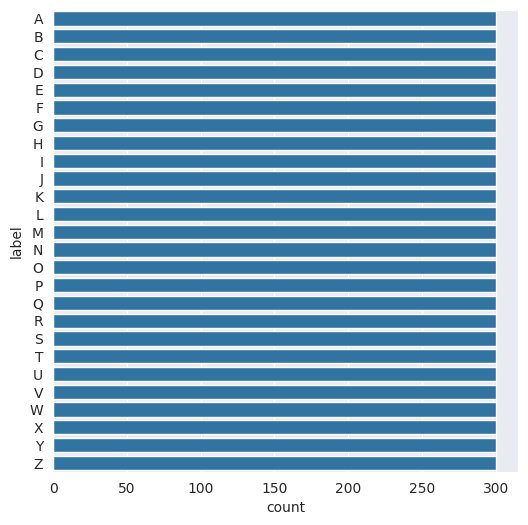

In [ ]:
# Plot distribusi gambar di setiap kelas
Label = df['label']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [ ]:
df['label'].value_counts()

,count
label,
A,300
B,300
C,300
D,300
E,300
F,300
G,300
H,300
I,300


### Data Preprocessing

#### Split Dataset

In [ ]:
def split_train_test(csv_filename, train_file, test_file, train_size=0.8):

    # Load dataset
    df = pd.read_csv(csv_filename)

    # Pisahkan fitur dan label
    if 'label' not in df.columns:
        raise ValueError("CSV harus memiliki kolom 'label'")

    X = df.drop(columns=['label'])
    y = df['label']

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_size,
        stratify=y,
        random_state=42
    )

    # Buat DataFrame untuk train dan test
    train_df = pd.concat([y_train.reset_index(drop=True), X_train.reset_index(drop=True)], axis=1)
    test_df = pd.concat([y_test.reset_index(drop=True), X_test.reset_index(drop=True)], axis=1)

    # Simpan ke CSV
    train_df.to_csv(train_file, index=False)
    test_df.to_csv(test_file, index=False)

    print(f"Dataset berhasil dibagi:")
    print(f"  Train Set: {train_df.shape[0]} sampel, {train_df.shape[1]} kolom")
    print(f"  Test Set:  {test_df.shape[0]} sampel, {test_df.shape[1]} kolom")

    return train_df, test_df

In [ ]:
train_df, test_df = split_train_test(
    "bisindo_landmarks_scaled.csv",
    'train.csv',
    'test.csv',
    train_size=0.8
)

Dataset berhasil dibagi:
  Train Set: 6240 sampel, 127 kolom
  Test Set:  1560 sampel, 127 kolom


## Modelling

In [ ]:
# Parameter
input_dim = 126  # 2 tangan x 21 landmark x 3 koordinat
epochs = 100
batch_size = 32

checkpoint_dir = './checkpoints'
saved_model_mlp_dir = './saved_models_mlp'

# Pastikan folder ada
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(saved_model_mlp_dir, exist_ok=True)

##### Function: Load Train and Test Dataset

def load_dataset(train_file, test_file):
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)

    # Pastikan kolom label tersedia
    if 'label' not in train_df.columns or 'label' not in test_df.columns:
        raise ValueError("File train dan test harus memiliki kolom 'label'.")

    # Kolom yang bukan fitur
    non_feature_columns = ['label', 'path', 'file_name']

    drop_train = [
        col for col in non_feature_columns
        if col in train_df.columns
    ]

    drop_test = [
        col for col in non_feature_columns
        if col in test_df.columns
    ]

    # Pisahkan fitur dan label
    X_train = train_df.drop(columns=drop_train).values
    y_train = train_df['label'].values

    X_test = test_df.drop(columns=drop_test).values
    y_test = test_df['label'].values

    # Encode labels
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_test = label_encoder.transform(y_test)

    return X_train, y_train, X_test, y_test, label_encoder

##### Load Dataset

X_train, y_train, X_test, y_test, label_encoder = load_dataset(
    'train.csv',
    'test.csv'
)

# Simpan LabelEncoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Label encoder berhasil dibuat dan disimpan.")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

num_classes = len(label_encoder.classes_)

print("Jumlah kelas:", num_classes)
print("Daftar kelas:", label_encoder.classes_)

Label encoder berhasil dibuat dan disimpan.
X_train shape: (6240, 126)
X_test shape : (1560, 126)
y_train shape: (6240,)
y_test shape : (1560,)
Jumlah kelas: 26
Daftar kelas: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [ ]:
# --- Multilayer Perceptron Model ---
def create_mlp_model(input_dim, num_classes):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# --- Callback MLP ---
mlp_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'best_model_mlp.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir='./logs/mlp'
    )
]

In [ ]:
# --- Training MLP ---
mlp_model = create_mlp_model(input_dim, num_classes)

print("\nTraining Multilayer Perceptron (MLP)...")

mlp_history = mlp_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=mlp_callbacks,
    verbose=1
)


Training Multilayer Perceptron (MLP)...
Epoch 1/100
179/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2602 - loss: 2.6111
Epoch 1: val_accuracy improved from None to 0.80833, saving model to ./checkpoints/best_model_mlp.h5



Epoch 1: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4268 - loss: 1.9340 - val_accuracy: 0.8083 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 2/100
184/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6907 - loss: 0.9269
Epoch 2: val_accuracy improved from 0.80833 to 0.88141, saving model to ./checkpoints/best_model_mlp.h5



Epoch 2: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7417 - loss: 0.7858 - val_accuracy: 0.8814 - val_loss: 0.4288 - learning_rate: 0.0010
Epoch 3/100
185/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8269 - loss: 0.5333
Epoch 3: val_accuracy improved from 0.88141 to 0.92821, saving model to ./checkpoints/best_model_mlp.h5



Epoch 3: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8413 - loss: 0.4848 - val_accuracy: 0.9282 - val_loss: 0.2708 - learning_rate: 0.0010
Epoch 4/100
184/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8753 - loss: 0.3786
Epoch 4: val_accuracy improved from 0.92821 to 0.96090, saving model to ./checkpoints/best_model_mlp.h5



Epoch 4: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8881 - loss: 0.3579 - val_accuracy: 0.9609 - val_loss: 0.1901 - learning_rate: 0.0010
Epoch 5/100
181/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9126 - loss: 0.2919
Epoch 5: val_accuracy improved from 0.96090 to 0.96987, saving model to ./checkpoints/best_model_mlp.h5


...


Epoch 9: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9657 - loss: 0.1293 - val_accuracy: 0.9853 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 10/100
185/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9664 - loss: 0.1212
Epoch 10: val_accuracy did not improve from 0.98526
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9696 - loss: 0.1148 - val_accuracy: 0.9833 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 11/100
180/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9740 - loss: 0.1013
Epoch 11: val_accuracy did not improve from 0.98526
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9732 - loss: 0.1022 - val_accuracy: 0.9853 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 12/100
185/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9773 - loss: 0.0847
Epoch 12: val_accuracy did not improve from 0.98526
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.0925 - val_accuracy:


Epoch 13: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9777 - loss: 0.0885 - val_accuracy: 0.9878 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 14/100
182/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9766 - loss: 0.0782
Epoch 14: val_accuracy did not improve from 0.98782
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9796 - loss: 0.0759 - val_accuracy: 0.9865 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 15/100
189/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9794 - loss: 0.0709
Epoch 15: val_accuracy did not improve from 0.98782
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9800 - loss: 0.0697 - val_accuracy: 0.9853 - val_loss: 0.0735 - learning_rate: 0.0010
Epoch 16/100
179/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9813 - loss: 0.0671
Epoch 16: val_accuracy did not improve from 0.98782
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9821 - loss: 0.0671 - val_accuracy


Epoch 20: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9857 - loss: 0.0525 - val_accuracy: 0.9897 - val_loss: 0.0700 - learning_rate: 0.0010
Epoch 21/100
188/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9871 - loss: 0.0476
Epoch 21: val_accuracy did not improve from 0.98974
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9877 - loss: 0.0464 - val_accuracy: 0.9885 - val_loss: 0.0620 - learning_rate: 0.0010
Epoch 22/100
187/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9856 - loss: 0.0464
Epoch 22: val_accuracy improved from 0.98974 to 0.99103, saving model to ./checkpoints/best_model_mlp.h5



Epoch 22: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9870 - loss: 0.0482 - val_accuracy: 0.9910 - val_loss: 0.0632 - learning_rate: 0.0010
Epoch 23/100
179/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0440
Epoch 23: val_accuracy did not improve from 0.99103
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9862 - loss: 0.0484 - val_accuracy: 0.9897 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 24/100
193/195 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9860 - loss: 0.0441
Epoch 24: val_accuracy did not improve from 0.99103
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9880 - loss: 0.0431 - val_accuracy: 0.9897 - val_loss: 0.0606 - learning_rate: 0.0010
Epoch 25/100
166/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9882 - loss: 0.0404
Epoch 25: val_accuracy did not improve from 0.99103
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9886 - loss: 0.0404 - val_accuracy


Epoch 29: finished saving model to ./checkpoints/best_model_mlp.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9897 - loss: 0.0362 - val_accuracy: 0.9917 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 30/100
188/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9887 - loss: 0.0332
Epoch 30: val_accuracy did not improve from 0.99167

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9909 - loss: 0.0314 - val_accuracy: 0.9904 - val_loss: 0.0580 - learning_rate: 0.0010
Epoch 31/100
191/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9916 - loss: 0.0298
Epoch 31: val_accuracy did not improve from 0.99167
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.9910 - val_loss: 0.0593 - learning_rate: 5.0000e-04
Epoch 32/100
183/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9929 - loss: 0.0259
Epoch 32: val_accuracy did not improve from 0.99167
195/195

## Evaluation and Visualization

In [ ]:
print("\nEvaluating MLP Model:")

# Evaluasi model MLP
mlp_loss, mlp_acc = mlp_model.evaluate(X_test, y_test)

# Ambil akurasi training terakhir
mlp_train_acc = mlp_history.history['accuracy'][-1]

print(f"Train Accuracy (MLP): {mlp_train_acc:.4f}")
print(f"Test Accuracy (MLP): {mlp_acc:.4f}")

# Classification Report
y_pred_mlp = mlp_model.predict(X_test).argmax(axis=1)

print("\nClassification Report (MLP):")
print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=label_encoder.classes_
))


Evaluating MLP Model:
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9904 - loss: 0.0534 
Train Accuracy (MLP): 0.9936
Test Accuracy (MLP): 0.9904
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report (MLP):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        60
           B       0.98      0.95      0.97        60
           C       0.97      0.98      0.98        60
           D       0.98      1.00      0.99        60
           E       1.00      1.00      1.00        60
           F       0.95      0.97      0.96        60
           G       1.00      1.00      1.00        60
           H       1.00      1.00      1.00        60
           I       1.00      1.00      1.00        60
           J       1.00      1.00      1.00        60
           K       1.00      1.00      1.00        60
           L       1.00      0.97      0.98        60
           M       0.95      0.95      0.95        60
           N       

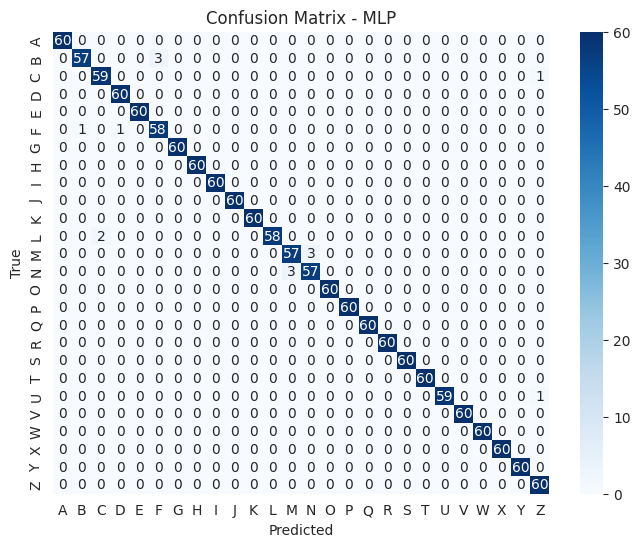

In [ ]:
# --- Confusion Matrix (MLP) ---
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Confusion Matrix - MLP')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

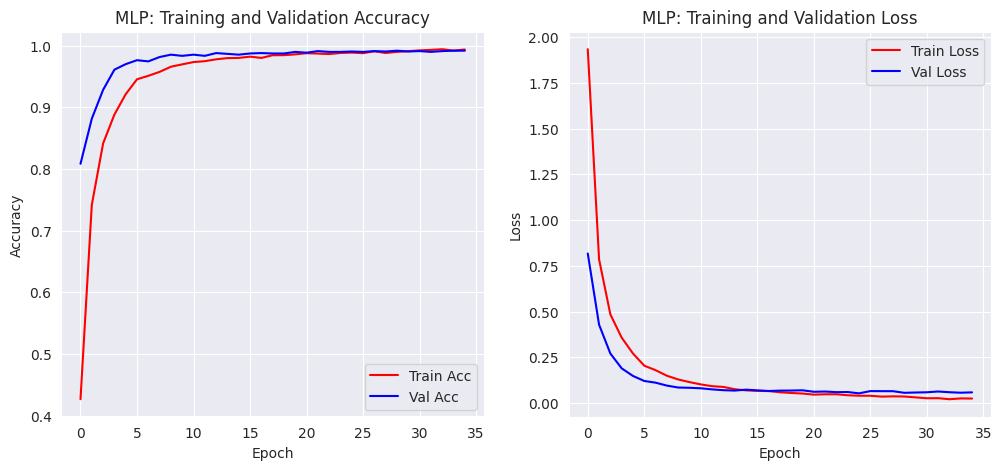

In [ ]:
# --- Plot Akurasi dan Loss MLP ---
acc = mlp_history.history['accuracy']
val_acc = mlp_history.history['val_accuracy']
loss = mlp_history.history['loss']
val_loss = mlp_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'r', label='Train Acc')
plt.plot(epochs_range, val_acc, 'b', label='Val Acc')
plt.title('MLP: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'r', label='Train Loss')
plt.plot(epochs_range, val_loss, 'b', label='Val Loss')
plt.title('MLP: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Model Conversion

### SavedModel (TensorFlow)

In [ ]:
mlp_model.export(saved_model_mlp_dir)

Saved artifact at './saved_models_mlp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 126), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  139541523079120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139541523079696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139541523081232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139541523081040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139541523075664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139541523080656: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
shutil.make_archive('saved_models_mlp', 'zip', 'saved_models_mlp')
from google.colab import files
files.download('saved_models_mlp.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### TensorFlow.js (TFJS)

In [ ]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    /content/saved_models_mlp/ \
    /content/mlp_tfjs_model

2026-06-10 23:59:10.532772: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781135950.550066    2004 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781135950.557007    2004 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781135950.575843    2004 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781135950.575903    2004 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781135950.575908    2004 computation_placer.cc:177] computation placer alr

In [ ]:
shutil.make_archive('mlp_tfjs_model', 'zip', 'mlp_tfjs_model')
files.download('mlp_tfjs_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip freeze > requirements.txt